In [2]:
import numpy as np
from sklearn.cluster import KMeans
from model.KMeans import kmeans

# The file uses whitespace, not commas
data = np.loadtxt(
    "data/homework_files/kmtest.csv",
    encoding="utf-8-sig"
)

k = 4

#My implementation of KMeans
my_labels, my_centroids = kmeans(data, k)

#SK-Learn's KMeans implementation for comparison
sklearn_model = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

sklearn_labels = sklearn_model.fit_predict(data)

print("My centroids:")
print(my_centroids)

print("\nScikit-learn centroids:")
print(sklearn_model.cluster_centers_)

my_inertia = np.sum(
    (data - my_centroids[my_labels]) ** 2
)

print("\nMy inertia:", my_inertia)
print("Scikit-learn inertia:", sklearn_model.inertia_)

My centroids:
[[15.5         5.        ]
 [ 9.8         9.6       ]
 [ 3.16666667  4.        ]
 [ 9.5         4.5       ]]

Scikit-learn centroids:
[[ 9.5         4.5       ]
 [15.5         5.        ]
 [ 3.16666667  4.        ]
 [ 9.8         9.6       ]]

My inertia: 18.333333333333332
Scikit-learn inertia: 18.333333333333332


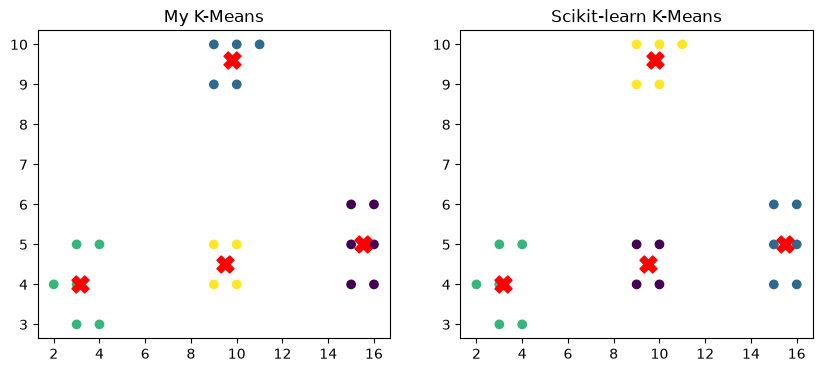

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(data[:, 0], data[:, 1], c=my_labels)
axes[0].scatter(
    my_centroids[:, 0],
    my_centroids[:, 1],
    color="red",
    marker="X",
    s=150
)
axes[0].set_title("My K-Means")

axes[1].scatter(data[:, 0], data[:, 1], c=sklearn_labels)
axes[1].scatter(
    sklearn_model.cluster_centers_[:, 0],
    sklearn_model.cluster_centers_[:, 1],
    color="red",
    marker="X",
    s=150
)
axes[1].set_title("Scikit-learn K-Means")

plt.show()

In [20]:
import importlib
import agents.document_agent as document_agent

importlib.reload(document_agent)

transformer_chunks = document_agent.process_documents(
    "data/pdf/transformers",
    chunk_size=1000,
    overlap=200
)

security_chunks = document_agent.process_documents(
    "data/pdf/LLM_Sec",
    chunk_size=1000,
    overlap=200
)

print("Transformer chunks:", len(transformer_chunks))
print("Security chunks:", len(security_chunks))

Processed Attention.pdf, page 1: 4 chunks
Processed Attention.pdf, page 2: 6 chunks
Processed Attention.pdf, page 3: 3 chunks
Processed Attention.pdf, page 4: 4 chunks
Processed Attention.pdf, page 5: 4 chunks
Processed Attention.pdf, page 6: 5 chunks
Processed Attention.pdf, page 7: 5 chunks
Processed Attention.pdf, page 8: 4 chunks
Processed Attention.pdf, page 9: 4 chunks
Processed Attention.pdf, page 10: 4 chunks
Processed Bert.pdf, page 1: 5 chunks
Processed Bert.pdf, page 2: 6 chunks
Processed Bert.pdf, page 3: 5 chunks
Processed Bert.pdf, page 4: 7 chunks
Processed Bert.pdf, page 5: 5 chunks
Processed Bert.pdf, page 6: 6 chunks
Processed Bert.pdf, page 7: 5 chunks
Processed Bert.pdf, page 8: 6 chunks
Processed Bert.pdf, page 9: 6 chunks
Processed Bert.pdf, page 10: 0 chunks
Processed Bert.pdf, page 12: 3 chunks
Processed Bert.pdf, page 13: 5 chunks
Processed Bert.pdf, page 14: 6 chunks
Processed Bert.pdf, page 15: 3 chunks
Processed Bert.pdf, page 16: 4 chunks
Processed LoRA.pdf

In [21]:
import importlib
import agents.document_agent as document_agent

importlib.reload(document_agent)

transformer_chunks = document_agent.process_documents(
    "data/pdf/transformers",
    chunk_size=500,
    overlap=200
)

security_chunks = document_agent.process_documents(
    "data/pdf/LLM_Sec",
    chunk_size=500,
    overlap=200
)

print("Transformer chunks:", len(transformer_chunks))
print("Security chunks:", len(security_chunks))

Processed Attention.pdf, page 1: 10 chunks
Processed Attention.pdf, page 2: 15 chunks
Processed Attention.pdf, page 3: 7 chunks
Processed Attention.pdf, page 4: 9 chunks
Processed Attention.pdf, page 5: 11 chunks
Processed Attention.pdf, page 6: 12 chunks
Processed Attention.pdf, page 7: 11 chunks
Processed Attention.pdf, page 8: 11 chunks
Processed Attention.pdf, page 9: 10 chunks
Processed Attention.pdf, page 10: 9 chunks
Processed Bert.pdf, page 1: 14 chunks
Processed Bert.pdf, page 2: 16 chunks
Processed Bert.pdf, page 3: 13 chunks
Processed Bert.pdf, page 4: 17 chunks
Processed Bert.pdf, page 5: 13 chunks
Processed Bert.pdf, page 6: 15 chunks
Processed Bert.pdf, page 7: 13 chunks
Processed Bert.pdf, page 8: 15 chunks
Processed Bert.pdf, page 9: 14 chunks
Processed Bert.pdf, page 10: 0 chunks
Processed Bert.pdf, page 12: 7 chunks
Processed Bert.pdf, page 13: 13 chunks
Processed Bert.pdf, page 14: 14 chunks
Processed Bert.pdf, page 15: 8 chunks
Processed Bert.pdf, page 16: 11 chunks

In [ ]:
import importlib
import agents.embedding_agent as embedding_agent

importlib.reload(embedding_agent)

transformer_embeddings = embedding_agent.create_embeddings(
    transformer_chunks
)

security_embeddings = embedding_agent.create_embeddings(
    security_chunks
)

print(
    "Transformer embeddings:",
    transformer_embeddings.shape
)

print(
    "Security embeddings:",
    security_embeddings.shape
)

Transformer embeddings: (758, 768)
Security embeddings: (736, 768)


In [24]:
assert len(transformer_embeddings) == len(transformer_chunks)
assert len(security_embeddings) == len(security_chunks)

print("Embedding counts are correct.")

Embedding counts are correct.


In [41]:
transformer_labels, transformer_centroids = kmeans(
    transformer_embeddings,
    k=10
)

print("Transformer labels:", transformer_labels.shape)
print("Transformer centroids:", transformer_centroids.shape)
print(
    "Cluster sizes:",
    np.bincount(transformer_labels)
)

Transformer labels: (758,)
Transformer centroids: (10, 768)
Cluster sizes: [134  70  84  76  75  85  58  44  71  61]


In [42]:
security_labels, security_centroids = kmeans(
    security_embeddings,
    k=10
)

print("Security labels:", security_labels.shape)
print("Security centroids:", security_centroids.shape)
print(
    "Cluster sizes:",
    np.bincount(security_labels)
)

Security labels: (736,)
Security centroids: (10, 768)
Cluster sizes: [ 70 130 122  49 149  49  41  23  47  56]


In [43]:
for chunk, label in zip(
    transformer_chunks,
    transformer_labels
):
    chunk["cluster"] = int(label)

In [44]:
for chunk, label in zip(
    security_chunks,
    security_labels
):
    chunk["cluster"] = int(label)

In [48]:
print(transformer_chunks[0]["cluster"])
print(security_chunks[10]["cluster"])

0
4


In [ ]:
from agents.clustering_agent import find_representatives
transformer_representatives = find_representatives(
    transformer_chunks,
    transformer_embeddings,
    transformer_labels,
    transformer_centroids
)

security_representatives = find_representatives(
    security_chunks,
    security_embeddings,
    security_labels,
    security_centroids
)

print(
    "Transformer representatives:",
    len(transformer_representatives)
)

print(
    "Security representatives:",
    len(security_representatives)
)

ImportError: cannot import name 'find_representatives' from 'agents.clustering_agent' (/Users/hxu10/Desktop/Homeworks/2026-Fall/Advance ML/Assignments /Assignment 1/agents/clustering_agent.py)

In [14]:
best_result = max(
    results,
    key=lambda result: result["silhouette"]
)

best_k = best_result["k"]
labels = best_result["labels"]
centroids = best_result["centroids"]

print("Recommended k:", best_k)
print("Silhouette:", best_result["silhouette"])

Recommended k: 9
Silhouette: 0.09980812653542079


In [15]:
representatives = []

for cluster_id in range(best_k):
    indices = np.where(labels == cluster_id)[0]

    cluster_embeddings = embeddings[indices]

    distances = np.sqrt(
        np.sum(
            (
                cluster_embeddings
                - centroids[cluster_id]
            ) ** 2,
            axis=1
        )
    )

    closest_position = np.argmin(distances)
    representative_index = indices[closest_position]

    representatives.append({
        "cluster": cluster_id,
        "chunk": chunks[representative_index],
    })

In [16]:
for representative in representatives:
    chunk = representative["chunk"]

    print(
        f"\n===== Cluster "
        f"{representative['cluster']} ====="
    )
    print("Source:", chunk["source"])
    print("Page:", chunk["page"])
    print(chunk["text"][:700])


===== Cluster 0 =====
Source: trillion_Params.pdf
Page: 6
of token routing dynamics. Each expert processes a ﬁxed batch-size of tokens modulated by the capacity factor. Each token is routed to the expert with the highest router probability, but each expert has a ﬁxed batch size of (total tokens / num experts)× capacity factor. If the tokens are unevenly dis- patched then certain experts will overﬂow (denoted by dotted red lines), resulting in these tokens not being processed by this layer. A larger capacity factor allevi- ates this overﬂow issue, but also increases computation and communication costs (depicted by padded white/empty slots). 2.2 Eﬃcient Sparse Routing We use Mesh-Tensorﬂow (MTF) (Shazeer et al., 2018) which is a library, with similar

===== Cluster 1 =====
Source: trillion_Params.pdf
Page: 1
instability. We address these with the introduction of the Switch Transformer. We simplify the MoE routing algorithm and design intuitive improved models with reduced communication 

In [17]:
from agents.topic_agent import create_topics

topics = create_topics(representatives)

In [18]:
for topic in topics:
    print(f"\n===== Cluster {topic['cluster']} =====")
    print("Representative source:", topic["source"])
    print("Page:", topic["page"])
    print(topic["result"])


===== Cluster 0 =====
Representative source: trillion_Params.pdf
Page: 6
Topic: Distributed Token Routing and Sparse Computing
Summary: The text discusses managing token routing dynamics, addressing overflow issues through capacity factors, and introducing Mesh-Tensorflow (MTF) for efficient distributed data and model parallel architectures.

===== Cluster 1 =====
Representative source: trillion_Params.pdf
Page: 1
Topic: Mixture-of-Experts Optimization
Summary: The work introduces methods and models, such as the Switch Transformer, to mitigate instability and significantly reduce communication and computational costs while training large, sparse, multilingual language models.

===== Cluster 2 =====
Representative source: Attention.pdf
Page: 10
Topic: Transformer Model Performance
Summary: The Transformer model, based entirely on attention, achieves a new state of the art for translation tasks and is significantly faster than recurrent architectures.

===== Cluster 3 =====
Representati

In [21]:
from agents.summary_agent import create_final_summary

final_summary = create_final_summary(topics)

print("FINAL MULTI-DOCUMENT SUMMARY")
print()
print(final_summary)

FINAL MULTI-DOCUMENT SUMMARY

The field of deep learning and Natural Language Processing (NLP) is characterized by advancements in model architecture, pre-training methods, and parameter-efficient adaptation techniques.

The Transformer model, which relies entirely on the attention mechanism, has significantly outperformed previous sequence transduction models, achieving a new state of the art in translation tasks. Pre-trained representations, exemplified by models like BERT, have demonstrated that these representations reduce the need for heavily-engineered task-specific architectures in NLP by achieving state-of-the-art performance. Performance comparisons across various language models, such as BiLSTM, GPT, and BERT, are often evaluated using benchmarks like GLUE.

To manage the complexity and scale of large, sparse, multilingual language models, optimization methods are crucial. Mixture-of-Experts (MoE) optimization methods, such as the Switch Transformer, are introduced to improve

In [1]:
from sklearn.metrics import silhouette_score
from model.KMeans import kmeans
import numpy as np

results = []

for k in [3, 10, 30]:
    labels, centroids = kmeans(embeddings, k=k)

    inertia = np.sum(
        (embeddings - centroids[labels]) ** 2
    )

    silhouette = silhouette_score(
        embeddings,
        labels
    )

    cluster_sizes = np.bincount(labels, minlength=k)

    results.append({
        "k": k,
        "labels": labels,
        "centroids": centroids,
        "inertia": inertia,
        "silhouette": silhouette
    })

    print(f"\nk = {k}")
    print(f"Inertia: {inertia:.4f}")
    print(f"Silhouette: {silhouette:.4f}")
    print(f"Smallest cluster: {cluster_sizes.min()}")
    print(f"Largest cluster: {cluster_sizes.max()}")

NameError: name 'embeddings' is not defined